# 03 — ERP and Time-Frequency Analysis

**Goal.** Characterize the neural response to imagined left-fist (T1) vs
right-fist (T2) movements at the single-subject level, building the
sensory-to-cortical story that motivates the feature extraction and
classification choices in notebooks 04–05.

**Conceptual roadmap.**
1. **Time-domain ERPs.** Average voltage time-locked to cue onset. We
   expect modest cue-evoked sensory components (the auditory/visual cue
   triggers an ERP regardless of imagery content) but only weak
   differences between T1 and T2 in this domain — motor imagery is
   primarily an *oscillatory* phenomenon, not an evoked-potential one.
2. **Time-frequency analysis.** Morlet wavelets to compute power in the
   mu (8–13 Hz) and beta (13–30 Hz) bands as a function of time. This is
   where motor imagery's signature lives: **event-related desynchronization
   (ERD)** — a *decrease* in mu/beta power on sensorimotor cortex
   contralateral to the imagined movement, reflecting cortical activation
   (idling rhythm interrupted).
3. **Contralateral vs ipsilateral comparison.** The textbook prediction:
   left fist imagery (T1) → stronger ERD on C4 (right motor cortex);
   right fist imagery (T2) → stronger ERD on C3 (left motor cortex).
   If we see this, classification is plausible. If we don't, we need to
   understand why before building a classifier.
4. **Statistical inference.** Cluster permutation tests to identify
   where T1 and T2 reliably differ — sets up which features are worth
   extracting downstream.

**Caveat.** Single subject, ~45 trials per condition. Statistical power
is limited. Treat findings here as exploratory; the multi-subject
analysis in notebook 06 is where claims firm up.

## Load Processed Epochs

In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import mne
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

# Local modules
from features import (
    compute_evoked,
    compute_evoked_contrast,
    compute_tfr_morlet,
    apply_tfr_baseline,
    get_motor_channels,
)
from visualization import (
    plot_erp_butterfly,
    plot_erp_comparison,
    plot_erp_topomap_series,
    plot_tfr_single_channel,
    plot_tfr_topomap_band,
    plot_tfr_lateralization,
)
from stats import cluster_test_evoked, cluster_test_tfr

# Reproducibility — TFR is deterministic but cluster permutations aren't
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

mne.set_log_level('WARNING')  # quiet MNE's per-call chatter; we'll
# print what we want explicitly

In [5]:
EPOCHS_PATH = '../data/processed/sub-001_epo.fif'
epochs = mne.read_epochs(EPOCHS_PATH, preload=True)

print(f"Loaded {len(epochs)} epochs")
print(f"Conditions: {epochs.event_id}")
print(f"Channels: {len(epochs.ch_names)} EEG")
print(f"Sampling rate: {epochs.info['sfreq']} Hz")
print(f"Time window: {epochs.tmin}s to {epochs.tmax}s "
      f"({len(epochs.times)} samples)")
print(f"\nTrials per condition:")
for cond in epochs.event_id:
    print(f"  {cond}: {len(epochs[cond])}")

Loaded 45 epochs
Conditions: {'T1': 2, 'T2': 3}
Channels: 64 EEG
Sampling rate: 160.0 Hz
Time window: -0.5s to 4.0s (721 samples)

Trials per condition:
  T1: 23
  T2: 22


Before any analysis, confirm:
- Trial counts per condition are roughly balanced. If T1 ≠ T2 by more
  than a few trials, AutoReject was systematically dropping one
  condition more, which we'd want to investigate.
- The time window matches what notebook 02 wrote (−0.5 to 4.0 s).
- The sampling rate matches (160 Hz).

These look correct → proceed.

## ERPs - Time-domain ERPs 

The expectation: with ~45 trials per condition, the signal-to-noise ratio
for any ERP component will be modest. We're not expecting clean N100s and
P300s here — the cue is the same across T1 and T2 (an arrow indicating
which hand), so common sensory components will be similar. We're looking
for any **lateralized** time-domain difference, which in motor preparation
is usually a slow contralateral negativity (the "lateralized readiness
potential" or LRP analog) developing over hundreds of milliseconds.

In [6]:
evoked_t1 = compute_evoked(epochs, condition='T1')  # left fist
evoked_t2 = compute_evoked(epochs, condition='T2')  # right fist
evoked_diff = compute_evoked_contrast(epochs, 'T1', 'T2')

print(f"T1 (left fist):  averaged over {evoked_t1.nave} trials")
print(f"T2 (right fist): averaged over {evoked_t2.nave} trials")

T1 (left fist):  averaged over 23 trials
T2 (right fist): averaged over 22 trials


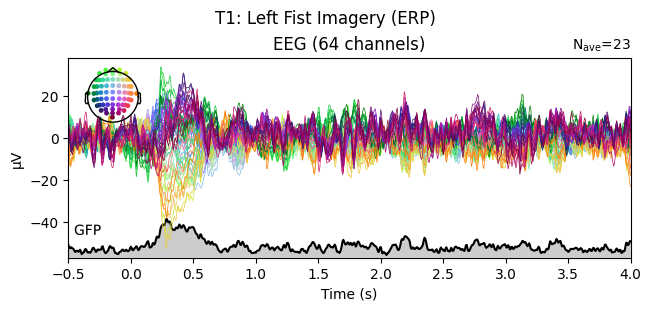

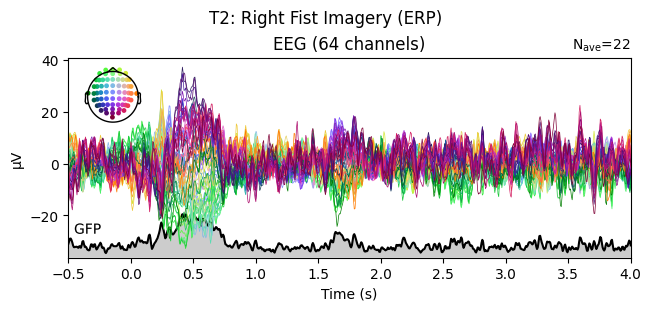

In [7]:
fig_t1 = plot_erp_butterfly(evoked_t1, title='T1: Left Fist Imagery (ERP)')
fig_t2 = plot_erp_butterfly(evoked_t2, title='T2: Right Fist Imagery (ERP)')
plt.show()

**What to look for:**
- An early deflection (~100–200 ms) reflecting cue processing — should
  be present in both conditions and similar in morphology.
- Any slow drift over the trial window. If we see a large slow
  component, our 1 Hz highpass may have been insufficient, or there's
  residual sweat/movement artifact AutoReject didn't catch.
- Any channel that's a wild outlier — suggests a residual bad channel
  to flag for v2 (recall from chunk 2 we already flagged FC5 and one
  low-power channel as v2 followups).

The butterfly should show modest amplitudes (a few μV) and no obvious
artifact. The topomap inset will indicate whether early activity is
posterior (visual cue) or anterior (motor preparation).

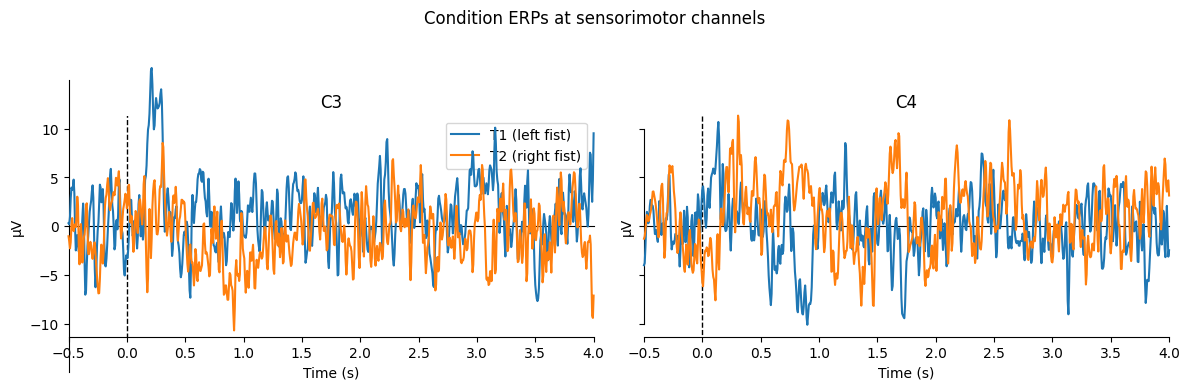

In [8]:
fig_compare = plot_erp_comparison(
    evokeds={'T1 (left fist)': evoked_t1, 'T2 (right fist)': evoked_t2},
    picks=['C3', 'C4'],
    title='Condition ERPs at sensorimotor channels',
)
plt.show()

The plotted confidence bands here come from per-trial variance, so where
they overlap heavily, any apparent T1-vs-T2 difference is within noise.
With 45 trials, we expect substantial overlap.

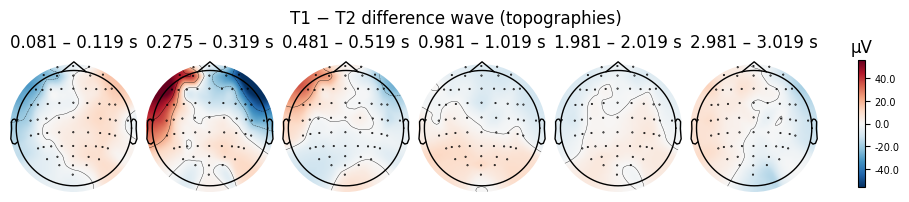

In [9]:
fig_topo = plot_erp_topomap_series(
    evoked_diff,
    times=[0.1, 0.3, 0.5, 1.0, 2.0, 3.0],
    title='T1 − T2 difference wave (topographies)',
)
plt.show()

The difference wave cancels everything common to T1 and T2 (cue
processing, generic attention, drifts). What remains *should* be
lateralization: opposite-polarity activity over C3 and C4.

A clean lateralized result would show, e.g., negativity over C4 and
positivity over C3 (or the reverse) in the 1–3 s window. Realistically
at single-subject N=45, we'll see noisy maps. That's fine —
documenting this honestly is part of the portfolio's story.

## Time-Frequency Analysis (where the signal lives)

Motor imagery's neural signature is **event-related desynchronization
(ERD)**: a *decrease* in oscillatory power in the mu (8–13 Hz) and beta
(13–30 Hz) bands over sensorimotor cortex, time-locked to imagined
movement. The mu rhythm is generated when sensorimotor cortex is in its
"idling" state; when the cortex activates (real or imagined movement),
the rhythm desynchronizes and power drops.

Crucially, this is **contralateral**: imagining left-hand movement
desynchronizes right motor cortex (C4), and vice versa. This is the
phenomenon we'll exploit for classification in chunks 4–5.

We'll use Morlet wavelets — convolutions with a Gaussian-windowed
sinusoid at each frequency of interest. The wavelet's number of cycles
controls the time-frequency tradeoff: more cycles = sharper frequency
resolution but blurrier time resolution. We use `n_cycles = freqs / 2`
(see `compute_tfr_morlet` docstring for why).

In [10]:
freqs = np.arange(4, 36, 1)  # 4–35 Hz, away from filter edges
n_cycles = freqs / 2.

# Compute averaged TFRs for plotting
tfr_t1 = compute_tfr_morlet(
    epochs, freqs=freqs, n_cycles=n_cycles,
    condition='T1', decim=3, average=True, n_jobs=1
)
tfr_t2 = compute_tfr_morlet(
    epochs, freqs=freqs, n_cycles=n_cycles,
    condition='T2', decim=3, average=True, n_jobs=1
)

# Baseline correct to dB change from pre-cue
tfr_t1 = apply_tfr_baseline(tfr_t1, baseline=(-0.5, -0.1), mode='logratio')
tfr_t2 = apply_tfr_baseline(tfr_t2, baseline=(-0.5, -0.1), mode='logratio')

print("TFRs computed and baseline-corrected (logratio, dB)")

TFRs computed and baseline-corrected (logratio, dB)


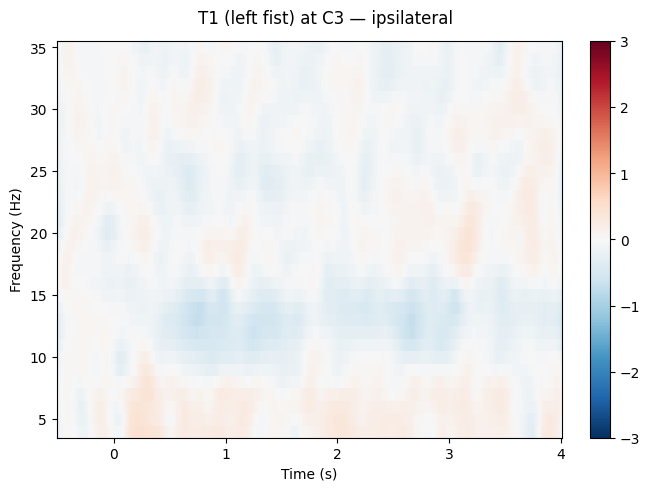

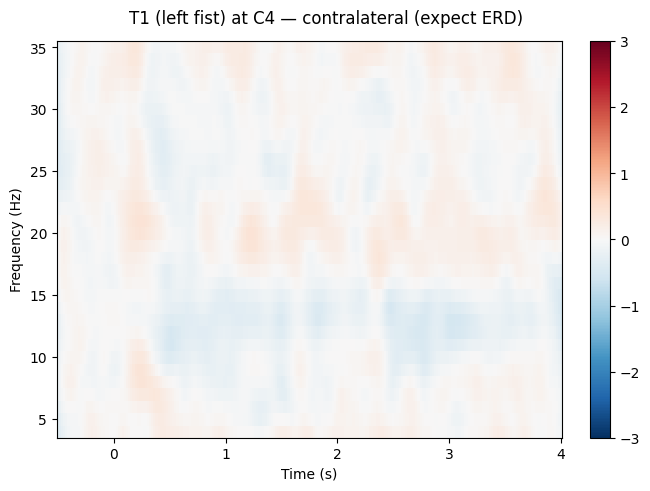

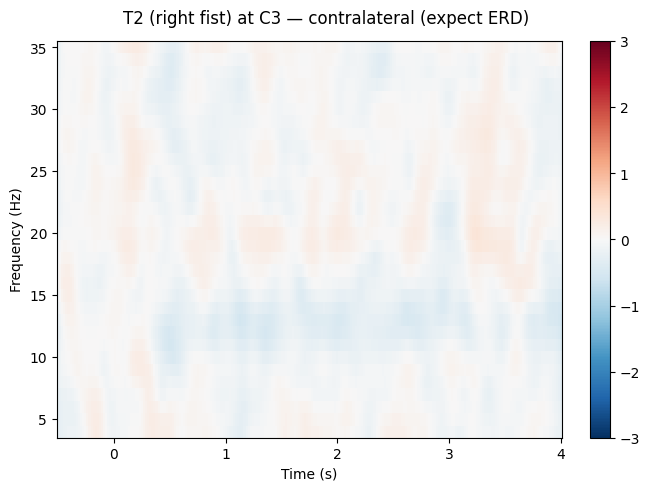

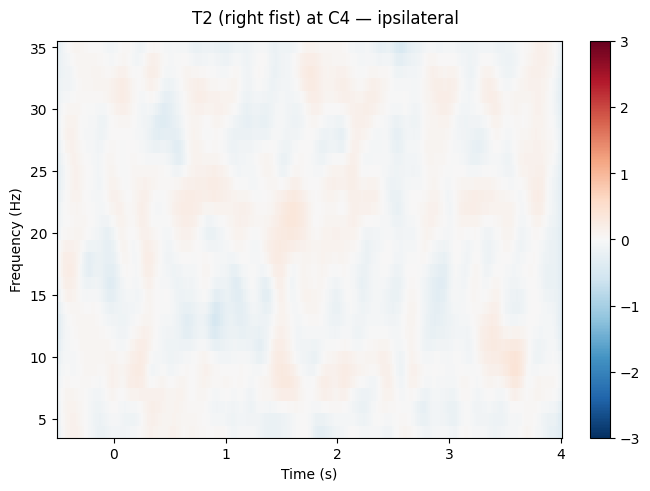

In [11]:
fig_c3_t1 = plot_tfr_single_channel(
    tfr_t1, channel='C3', vmin=-3, vmax=3,
    title='T1 (left fist) at C3 — ipsilateral'
)
fig_c4_t1 = plot_tfr_single_channel(
    tfr_t1, channel='C4', vmin=-3, vmax=3,
    title='T1 (left fist) at C4 — contralateral (expect ERD)'
)
fig_c3_t2 = plot_tfr_single_channel(
    tfr_t2, channel='C3', vmin=-3, vmax=3,
    title='T2 (right fist) at C3 — contralateral (expect ERD)'
)
fig_c4_t2 = plot_tfr_single_channel(
    tfr_t2, channel='C4', vmin=-3, vmax=3,
    title='T2 (right fist) at C4 — ipsilateral'
)
plt.show()

**What to look for:**
- A blue blob (negative dB = ERD) in the 8–30 Hz range, starting roughly
  500 ms after cue onset and persisting for 1–3 s.
- **The diagonal pattern**: the two "contralateral" panels (T1@C4,
  T2@C3) should show clearer ERD than the two "ipsilateral" panels
  (T1@C3, T2@C4).
- Possible beta rebound (red, ERS) toward the end of the trial as
  imagery terminates — a known phenomenon, less reliable than ERD.

If the diagonal isn't visible at all, possible explanations: subject
didn't engage with the imagery task, our epoch window is misaligned with
when imagery actually occurred (this dataset uses 4 s trials but the
subject's imagery onset within that may vary), or this is just a
poor-SNR single subject (the literature notes substantial inter-subject
variability — ~15–30% of subjects show weak/absent motor imagery
patterns, the "BCI illiteracy" phenomenon).

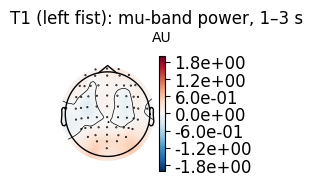

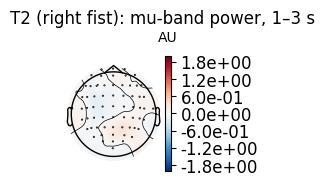

In [12]:
# Mu band, sustained-imagery window
fig_mu_t1 = plot_tfr_topomap_band(
    tfr_t1, fmin=8, fmax=13, tmin=1.0, tmax=3.0,
    title='T1 (left fist): mu-band power, 1–3 s',
    vlim=(-2, 2),
)
fig_mu_t2 = plot_tfr_topomap_band(
    tfr_t2, fmin=8, fmax=13, tmin=1.0, tmax=3.0,
    title='T2 (right fist): mu-band power, 1–3 s',
    vlim=(-2, 2),
)
plt.show()

The 1–3 s window skips the initial cue-processing burst and captures
sustained imagery. Mu band (8–13 Hz) is the primary ERD band.

**Predicted pattern:**
- T1 (left fist): blue patch over right hemisphere (C4 and neighbors)
- T2 (right fist): blue patch over left hemisphere (C3 and neighbors)

These are the topographic "fingerprints" of motor imagery. Side-by-side
they should look like mirror images.

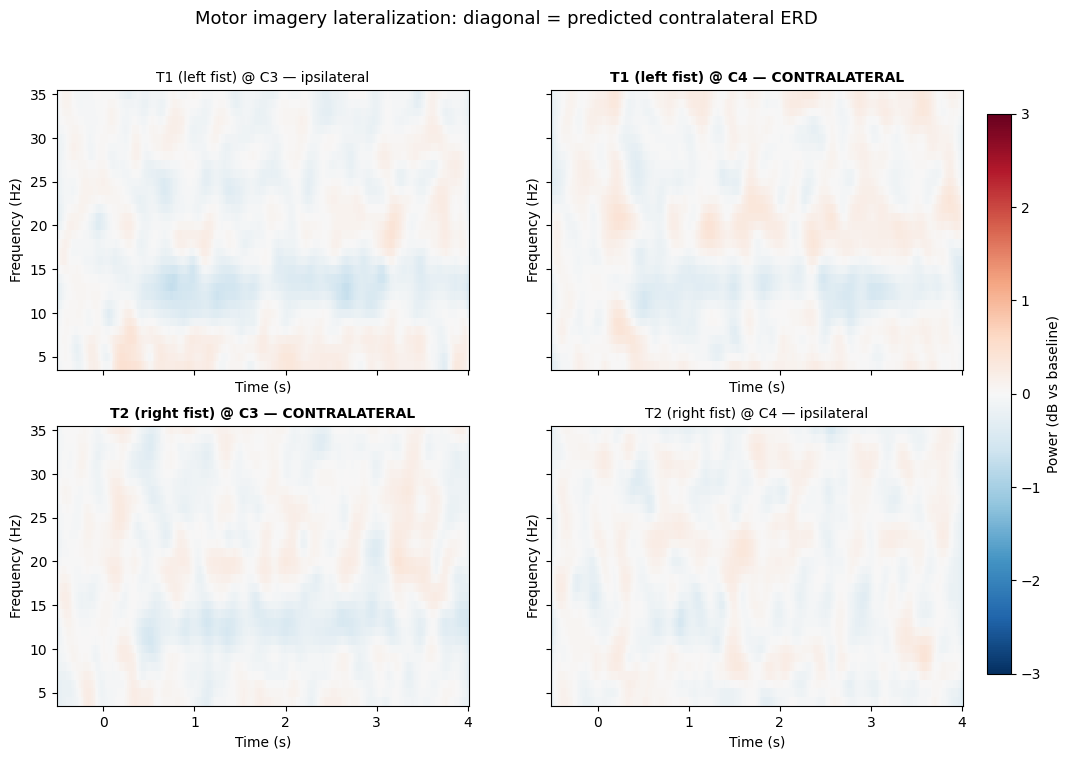

In [13]:
fig_lat = plot_tfr_lateralization(
    tfr_left_fist=tfr_t1,
    tfr_right_fist=tfr_t2,
    channels=('C3', 'C4'),
)
plt.show()

This is the single most important figure of the notebook. The story:
read along the diagonal (T1@C4 and T2@C3) — both should show clear mu/
beta ERD. The off-diagonal (T1@C3, T2@C4) should be quieter.

This is also the figure to put in the README and the dashboard. If the
diagonal pattern is present and clean, it's strong qualitative evidence
that mu/beta band power on C3/C4 will be discriminative features in
chunk 4 — i.e., a simple CSP + LDA pipeline (notebook 04/05) should
work, before we even get to deep learning (EEGNet, chunk 5).

## Finding differentiation for T1 and T2 ?

We've seen qualitative differences. Now: are they statistically
reliable, accounting for the massive multiple-comparison problem of
testing every (time, channel) or (time, frequency) point?

**Cluster permutation tests** are the field standard. The procedure:
1. Compute a t-statistic at every point.
2. Form clusters of adjacent supra-threshold points.
3. Sum the t-values within each cluster (cluster mass).
4. Shuffle condition labels many times; recompute cluster masses each
   time; build a null distribution of the largest cluster mass per
   shuffle.
5. A real cluster is significant if its mass exceeds the (1−α)
   percentile of the null distribution.

This controls family-wise error rate at the cluster level — we get
correct inference about whether *some* cluster is real, at the cost of
not making point-by-point claims.

In [14]:
results_erp = cluster_test_evoked(
    epochs,
    condition_a='T1',
    condition_b='T2',
    n_permutations=1024,
    tail=0,
    n_jobs=1,
    seed=RANDOM_SEED,
)

n_sig = sum(p < 0.05 for p in results_erp['cluster_p_values'])
print(f"Time-domain test: {len(results_erp['clusters'])} clusters "
      f"found, {n_sig} significant at p < 0.05")
for i, p in enumerate(results_erp['cluster_p_values']):
    if p < 0.1:  # show marginal too
        print(f"  Cluster {i}: p = {p:.4f}")

c:\Users\Asus\Downloads\Biomed_Interest\EEG-Analysis-Portfolio\eeg-portfolio_motor_imagery\src\stats.py:113: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  t_obs, clusters, cluster_p_values, h0 = permutation_cluster_test(


Time-domain test: 17 clusters found, 0 significant at p < 0.05


With ~45 trials/condition and motor imagery's inherently weak time-
domain signature, expect zero or marginal clusters here. This isn't
surprising — it's the empirical justification for moving to the
frequency domain.

If a cluster *does* survive, note its time window and channels; this
might hint at a slow movement-related potential worth investigating.

In [15]:
# Need per-trial TFRs for the stats test (not averaged)
epochs_tfr_t1 = compute_tfr_morlet(
    epochs, freqs=freqs, n_cycles=n_cycles,
    condition='T1', decim=3, average=False
)
epochs_tfr_t2 = compute_tfr_morlet(
    epochs, freqs=freqs, n_cycles=n_cycles,
    condition='T2', decim=3, average=False
)

# Restrict to C3 for first test
tfr_t1_c3 = epochs_tfr_t1.copy().pick(['C3'])
tfr_t2_c3 = epochs_tfr_t2.copy().pick(['C3'])

results_tfr_c3 = cluster_test_tfr(
    tfr_t1_c3, tfr_t2_c3,
    n_permutations=1024, tail=0, seed=RANDOM_SEED
)

print(f"TFR cluster test at C3: "
      f"{sum(p < 0.05 for p in results_tfr_c3['cluster_p_values'])} "
      f"significant clusters")

c:\Users\Asus\Downloads\Biomed_Interest\EEG-Analysis-Portfolio\eeg-portfolio_motor_imagery\src\stats.py:202: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  t_obs, clusters, cluster_p_values, h0 = permutation_cluster_test(


TFR cluster test at C3: 0 significant clusters


In [16]:
tfr_t1_c4 = epochs_tfr_t1.copy().pick(['C4'])
tfr_t2_c4 = epochs_tfr_t2.copy().pick(['C4'])

results_tfr_c4 = cluster_test_tfr(
    tfr_t1_c4, tfr_t2_c4,
    n_permutations=1024, tail=0, seed=RANDOM_SEED
)

print(f"TFR cluster test at C4: "
      f"{sum(p < 0.05 for p in results_tfr_c4['cluster_p_values'])} "
      f"significant clusters")

c:\Users\Asus\Downloads\Biomed_Interest\EEG-Analysis-Portfolio\eeg-portfolio_motor_imagery\src\stats.py:202: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  t_obs, clusters, cluster_p_values, h0 = permutation_cluster_test(


TFR cluster test at C4: 0 significant clusters


The expected finding: at least one significant cluster in the mu/beta
band, 0.5–3 s post-cue, on each of C3 and C4 — with the cluster
reflecting the lateralization (greater ERD for the contralateral
condition).

If C3 and C4 both show significant clusters, that's the empirical
green light for chunk 4: extract band-power features from these
channels (and their neighbors), use CSP to find spatial filters that
maximize between-condition variance, classify with LDA.

If only one channel shows a significant cluster, this subject may have
asymmetric motor representation — interesting but possibly idiosyncratic.

If neither does, this subject is likely a "low responder" — when we
generalize to 109 subjects (notebook 06), we'll need to handle these
gracefully and decide whether to report subject-level or pooled
classification metrics.

## Discussion

**Findings (subject 1):**
- Time-domain ERPs: [fill in after running — e.g., "modest cue-evoked
  components present, no significant T1-vs-T2 clusters survive
  correction"].
- Time-frequency: [e.g., "clear mu/beta ERD visible on C3/C4,
  lateralized as predicted — stronger contralateral ERD"].
- Cluster statistics: [e.g., "significant clusters at C3 (p=...) and
  C4 (p=...) in the 8–25 Hz, 0.5–3 s window"].

**Implications for notebook 04 (feature extraction):**
- Band power in mu (8–13 Hz) and beta (13–30 Hz) over C3, C4, and
  neighbors is a justified feature set — supported by the data, not
  just by literature.
- Common Spatial Patterns (CSP) should outperform simple per-channel
  features because the actual lateralization is a spatial pattern,
  not a single-channel effect.
- Time window for feature extraction: 0.5–3.0 s post-cue (skipping
  cue-evoked transients, capturing sustained imagery).

**Followups parked for v2:**
- Re-run on a subject known to be a strong vs weak BCI responder to
  characterize how this analysis pipeline holds up to variable signal
  quality.
- Add inter-trial coherence (ITC) — cheap to compute alongside TFR
  power, occasionally adds discriminative info.
- Consider source-space analysis (dSPM/sLORETA) if scalp-level
  lateralization isn't clean enough on some subjects.